In [1]:
from synthetic_data import distributions, generate_sample_csv
import matplotlib.pyplot as plt

In [2]:
def predator_prey_model(y, t, params):
    X, Y = y
    rho, K, kappa1, kappa2, theta = params
    ddt_X = rho * X * (1 - X / K) - kappa1 * X * Y
    ddt_Y = kappa2 * X * Y - theta * Y
    return [ddt_X, ddt_Y]

In [3]:
n_indivs = 15
n_obs = 10
max_day_number = 300
err_b = 0.001
pop_param_info = [
    ("rho", 0.06, 0.2, distributions["lognormal"]),
    # ("K", 1e9, 0.2, distributions["lognormal"]),
    ("K", 1e9, 0, distributions["lognormal"]),
    # ("kappa1", 6e-9, 0.2, distributions["lognormal"]),
    ("kappa1", 6e-9, 0, distributions["lognormal"]),
    # ("kappa2", 0.3e-10, 0.3e-11, distributions["normal"]),
    ("kappa2", 0.3e-10, 0, distributions["normal"]),
    # ("theta", 0.1e-5, 1.0, distributions["lognormal"]),
    ("theta", 0.1e-5, 0, distributions["lognormal"]),
]
obs_var_info = [
    # ("X", 1.3e8, 0.2, distributions["lognormal"], "combined1", distributions["normal"]),
    ("X", 1.3e8, 0, distributions["lognormal"], "combined1", distributions["normal"]),
    # ("Y", 7e6, 0.2, distributions["lognormal"], "combined1", distributions["normal"]),
    ("Y", 7e6, 0, distributions["lognormal"], "combined1", distributions["normal"]),
]
obs_times_all, observations_all, _ = generate_sample_csv(
    # f"sahoo1_n{n_indivs}_o{n_obs}_d{max_day_number}",
    f"sahoo_only_rho",
    predator_prey_model,
    pop_param_info,
    obs_var_info,
    n_indivs,
    n_obs,
    max_day_number=300,
    err_a=0,
    err_b=err_b,
)

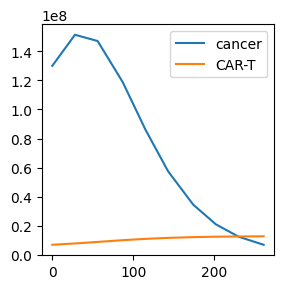

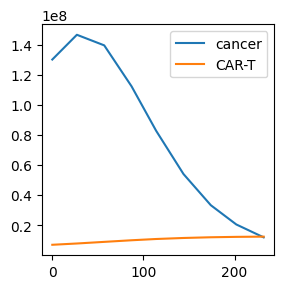

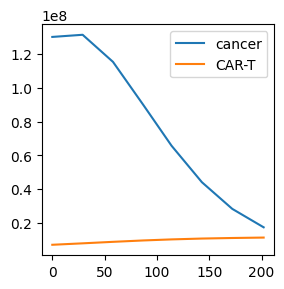

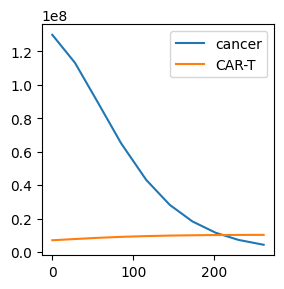

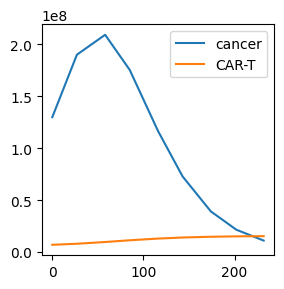

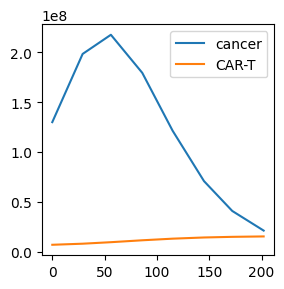

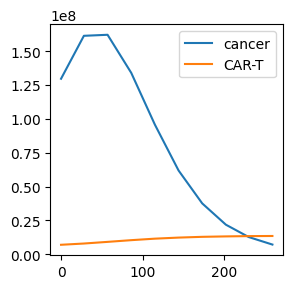

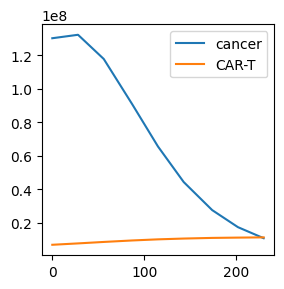

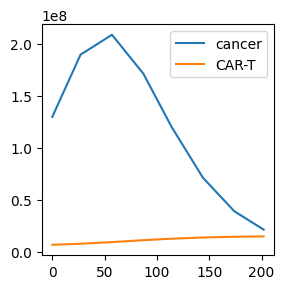

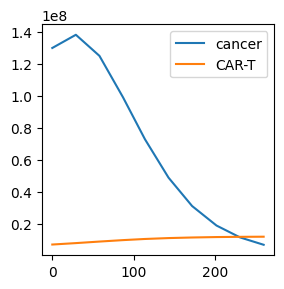

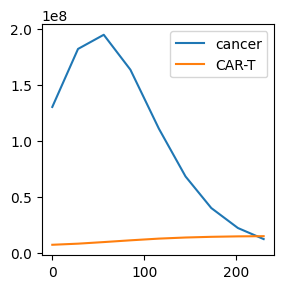

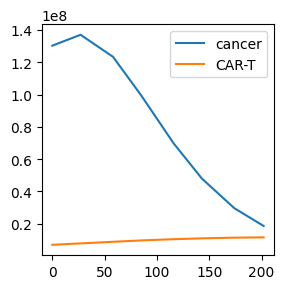

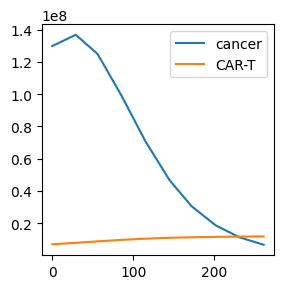

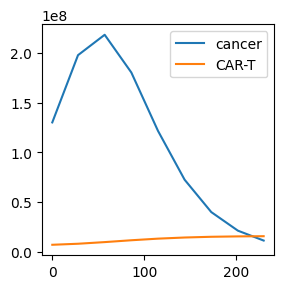

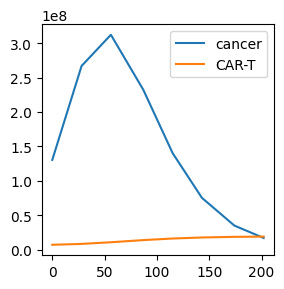

In [4]:
for times, obs in zip(obs_times_all, observations_all):
    plt.figure(figsize=(3, 3))
    plt.plot(times, obs[0], label="cancer")
    plt.plot(times, obs[1], label="CAR-T")
    plt.legend()
    plt.show()